In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

YOLO-Kaggle Results

In [56]:

# Daten aus der Benutzereingabe
data = [
    {
        "Fold": 1,
        "mAP50": 0.994592,
        "mAP50-95": 0.819206,
        "precision": [0.9772674114421703],
        "recall": [1.0]
    },
    {
        "Fold": 2,
        "mAP50": 0.994444,
        "mAP50-95": 0.831578,
        "precision": [0.9797221042867775],
        "recall": [1.0]
    },
    {
        "Fold": 3,
        "mAP50": 0.994600,
        "mAP50-95": 0.788892,
        "precision": [1.0],
        "recall": [0.9751540154585319]
    },
    {
        "Fold": 4,
        "mAP50": 0.985325,
        "mAP50-95": 0.808739,
        "precision": [0.9987336240133619],
        "recall": [0.9615384615384616]
    },
    {
        "Fold": 5,
        "mAP50": 0.995000,
        "mAP50-95": 0.851857,
        "precision": [0.9994167272567542],
        "recall": [1.0]
    }
]

df = pd.DataFrame(data)

# Werte aus den Listen extrahieren (da nur 1 Klasse/Wert vorhanden ist)
df['precision'] = df['precision'].apply(lambda x: x[0])
df['recall'] = df['recall'].apply(lambda x: x[0])

# Zusammenfassung berechnen
summary = df.drop(columns=['Fold']).agg(['mean', 'std'])

round(summary.T.rename(columns={"mean": "Mean", "std": "Std +-"}),3)

,Mean,Std +-
mAP50,0.993,0.004
mAP50-95,0.820,0.024
precision,0.991,0.011
recall,0.987,0.018


In [57]:
df.style.hide(axis="index")

Fold,mAP50,mAP50-95,precision,recall
1,0.994592,0.819206,0.977267,1.000000
2,0.994444,0.831578,0.979722,1.000000
3,0.994600,0.788892,1.000000,0.975154
4,0.985325,0.808739,0.998734,0.961538
5,0.995000,0.851857,0.999417,1.000000


RF-DETR-Kaggle Results

In [3]:
precision_rfdetr_kaggle = 1
recall_rfdetr_kaggle = 1
f1_rfdetr_kaggle = 2*(precision_rfdetr_kaggle*recall_rfdetr_kaggle)/(precision_rfdetr_kaggle+recall_rfdetr_kaggle)


rfdetr_kaggle_val = {
    "rf-detr/precision": 1.0,
    "rf-detr/recall": 1,
    "rf-detr/f1": f1_rfdetr_kaggle,
    "rf-detr/mAP50": 1.0,
    "rf-detr/mAP50-95": 0.77
}

In [3]:
# 1. Daten in eine vergleichbare Struktur bringen
metrics = ["Precision",'Recall',"F1", 'mAP@50', 'mAP@[50:95]']
yolo_values = [yolo_kaggle_val["kaggle/precision"], yolo_kaggle_val['kaggle/recall'],yolo_kaggle_val["kaggle/f1"] ,yolo_kaggle_val['kaggle/mAP50'], yolo_kaggle_val['kaggle/mAP50-95']]
rfdetr_values = [rfdetr_kaggle_val["rf-detr/precision"], rfdetr_kaggle_val['rf-detr/recall'],rfdetr_kaggle_val["rf-detr/f1"] ,rfdetr_kaggle_val['rf-detr/mAP50'], rfdetr_kaggle_val['rf-detr/mAP50-95']]

# 2. DataFrame für Matplotlib erstellen
data = {
    'Metric': metrics * 2,
    'Model': ['YOLO'] * len(metrics) + ['RF-DETR'] * len(metrics),
    'Value': yolo_values + rfdetr_values
}
df = pd.DataFrame(data)

# Werte für die Gruppierung vorbereiten
fig, ax = plt.subplots(figsize=(10, 6))
bar_width = 0.35
index = np.arange(len(metrics))

# Daten für die Modelle filtern
df_yolo = df[df['Model'] == 'YOLO']
df_rfdetr = df[df['Model'] == 'RF-DETR']

# Balken für YOLO plotten (links in der Gruppe)
bar1 = ax.bar(index, df_yolo['Value'], bar_width, label='YOLO', color='#36A2EB')

# Balken für RF-DETR plotten (rechts in der Gruppe)
bar2 = ax.bar(index + bar_width, df_rfdetr['Value'], bar_width, label='RF-DETR', color='#FF6384')

# 3. Diagramm formatieren
ax.set_xlabel('Evaluation Metric', fontsize=12)
ax.set_ylabel('Value', fontsize=12)
ax.set_title('Metrics comparison (Dataset B)', fontsize=14)
ax.set_xticks(index + bar_width / 2)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.05) # Y-Achse von 0 bis 1.05
ax.legend(loc='lower right')
ax.grid(axis='y', linestyle='--', alpha=0.6)

# 4. Werte auf die Balken schreiben
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # 3 Punkte vertikaler Versatz
                    textcoords="offset points",
                    ha='center', va='bottom',
                    fontsize=9)

add_labels(bar1)
add_labels(bar2)

plt.tight_layout()
plt.show()

NameError: name 'yolo_kaggle_val' is not defined

Yolo-Roboflow Results

In [24]:
# Deine Ergebnisse aus der 5-Fold Cross-Validation
data = [
    {
        "fold": 1,
        "mAP50": 0.817217,
        "mAP50-95": 0.563044,
        "precision": [0.7514621966286971, 0.9671146226696267],
        "recall": [0.5702702702702702, 0.9166666666666666]
    },
    {
        "fold": 2,
        "mAP50": 0.837757,
        "mAP50-95": 0.589359,
        "precision": [0.7385323545021348, 0.9627684545208934],
        "recall": [0.6494995472899632, 0.9715799732608127]
    },
    {
        "fold": 3,
        "mAP50": 0.835691,
        "mAP50-95": 0.567396,
        "precision": [0.7381310342963431, 0.9619391630191857],
        "recall": [0.6630434782608695, 0.9468563665758085]
    },
    {
        "fold": 4,
        "mAP50": 0.825140,
        "mAP50-95": 0.579171,
        "precision": [0.7367265344526664, 0.9684008740259846],
        "recall": [0.6235435144157984, 0.9596541786743515]
    },
    {
        "fold": 5,
        "mAP50": 0.824331,
        "mAP50-95": 0.585665,
        "precision": [0.6915238029656346, 0.9463481568322523],
        "recall": [0.6657824933687002, 0.976878612716763]
    }
]

# DataFrame erstellen
df = pd.DataFrame(data)

# Precision & Recall Listen aufsplitten: Index 0 = Defect, Index 1 = Glass
df['precision_defect'] = df['precision'].apply(lambda x: x[0])
df['precision_glass'] = df['precision'].apply(lambda x: x[1])
df['recall_defect'] = df['recall'].apply(lambda x: x[0])
df['recall_glass'] = df['recall'].apply(lambda x: x[1])

# Alte Spalten entfernen und sortieren
df_final = df.drop(columns=['precision', 'recall'])
df_final = df_final[['fold', 'mAP50', 'mAP50-95', 
                     'precision_defect', 'precision_glass', 
                     'recall_defect', 'recall_glass']]

# Berechnung von Mittelwert (mean) und Standardabweichung (std)
summary = df_final.drop(columns=['fold']).agg(['mean', 'std'])

round(summary.T.rename(columns={"mean": "Mean", "std": "Std +-"}),3)

,Mean,Std +-
mAP50,0.828,0.009
mAP50-95,0.577,0.011
precision_defect,0.731,0.023
precision_glass,0.961,0.009
recall_defect,0.634,0.040
recall_glass,0.954,0.024


RF-DETR-Roboflow Results

In [6]:
TP=173
TN=141
FP=50
FN=55

precision_rfdetr = TP/(TP+FP)
recall_rfdetr = TP/(TP+FN)
f1_rfdetr = 2*(precision_rfdetr*recall_rfdetr)/(precision_rfdetr + recall_rfdetr)
rfdetr_roboflow = {
    "rfdetr/precision": precision_rfdetr,
    "rfdetr/recall": recall_rfdetr,
    "rfdetr/F1": f1_rfdetr,
    "rfdetr/mAP50": 0.84,
    "rfdetr/mAP50-95": 0.59

}

rfdetr_roboflow

{'rfdetr/precision': 0.7757847533632287,
 'rfdetr/recall': 0.7587719298245614,
 'rfdetr/F1': 0.7671840354767184,
 'rfdetr/mAP50': 0.84,
 'rfdetr/mAP50-95': 0.59}

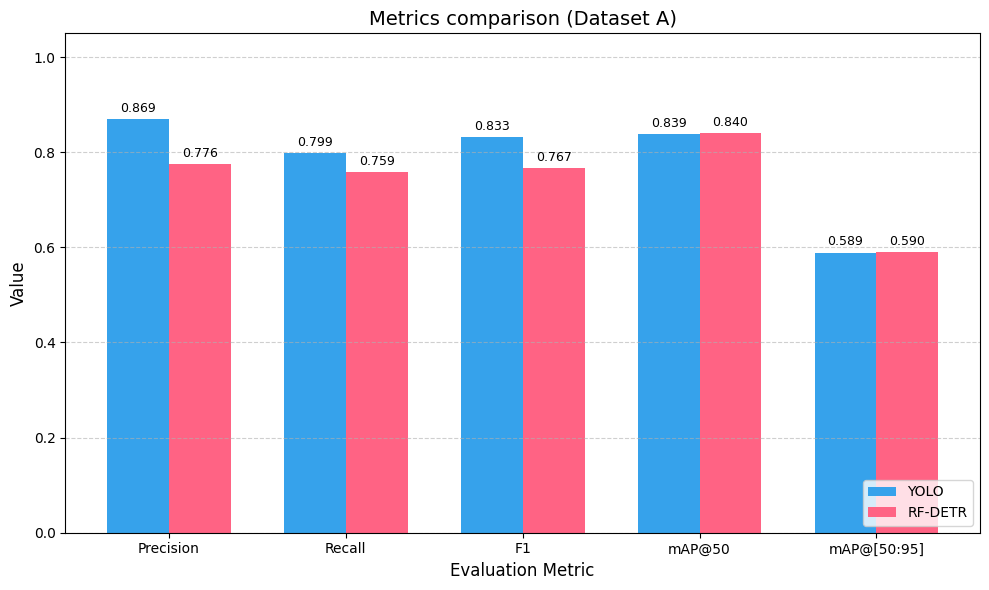

In [7]:
### Plot the results
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Daten in eine vergleichbare Struktur bringen
metrics = ["Precision",'Recall',"F1", 'mAP@50', 'mAP@[50:95]']
yolo_values = [yolo_roboflow["yolo/precision"], yolo_roboflow['yolo/recall'],yolo_roboflow["yolo/f1"], yolo_roboflow['yolo/mAP50'], yolo_roboflow['yolo/mAP50-95']]
rfdetr_values = [rfdetr_roboflow["rfdetr/precision"], rfdetr_roboflow['rfdetr/recall'],rfdetr_roboflow["rfdetr/F1"] ,rfdetr_roboflow['rfdetr/mAP50'], rfdetr_roboflow['rfdetr/mAP50-95']]

# 2. DataFrame für Matplotlib erstellen
data = {
    'Metric': metrics * 2,
    'Model': ['YOLO'] * len(metrics) + ['RF-DETR'] * len(metrics),
    'Value': yolo_values + rfdetr_values
}
df = pd.DataFrame(data)

# Werte für die Gruppierung vorbereiten
fig, ax = plt.subplots(figsize=(10, 6))
bar_width = 0.35
index = np.arange(len(metrics))

# Daten für die Modelle filtern
df_yolo = df[df['Model'] == 'YOLO']
df_rfdetr = df[df['Model'] == 'RF-DETR']

# Balken für YOLO plotten (links in der Gruppe)
bar1 = ax.bar(index, df_yolo['Value'], bar_width, label='YOLO', color='#36A2EB')

# Balken für RF-DETR plotten (rechts in der Gruppe)
bar2 = ax.bar(index + bar_width, df_rfdetr['Value'], bar_width, label='RF-DETR', color='#FF6384')

# 3. Diagramm formatieren
ax.set_xlabel('Evaluation Metric', fontsize=12)
ax.set_ylabel('Value', fontsize=12)
ax.set_title('Metrics comparison (Dataset A)', fontsize=14)
ax.set_xticks(index + bar_width / 2)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.05) # Y-Achse von 0 bis 1.05
ax.legend(loc='lower right')
ax.grid(axis='y', linestyle='--', alpha=0.6)

# 4. Werte auf die Balken schreiben
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # 3 Punkte vertikaler Versatz
                    textcoords="offset points",
                    ha='center', va='bottom',
                    fontsize=9)

add_labels(bar1)
add_labels(bar2)

plt.tight_layout()
plt.show()

Training RF-DETR- Dataset B

In [35]:
# 1. Metrik-Namen definieren (in der korrekten COCO-Reihenfolge)
metric_names = [
    "AP (IoU=0.50:0.95) | area=all",
    "AP (IoU=0.50)      | area=all",
    "AP (IoU=0.75)      | area=all",
    "AP (IoU=0.50:0.95) | area=small",
    "AP (IoU=0.50:0.95) | area=medium",
    "AP (IoU=0.50:0.95) | area=large",
    "AR (IoU=0.50:0.95) | maxDets=1",
    "AR (IoU=0.50:0.95) | maxDets=10",
    "AR (IoU=0.50:0.95) | maxDets=100",
    "AR (IoU=0.50:0.95) | area=small",
    "AR (IoU=0.50:0.95) | area=medium",
    "AR (IoU=0.50:0.95) | area=large"
]

# 2. Daten als Listen definieren
fold_1 = [0.797, 1.000, 0.941, 0.647, 0.759, 0.911, 0.710, 0.832, 0.832, 0.700, 0.796, 0.950]
fold_2 = [0.863, 0.970, 0.970, 0.567, 0.870, 1.000, 0.772, 0.882, 0.885, 0.625, 0.897, 1.000]
fold_3 = [0.915, 1.000, 1.000, 0.855, 0.898, 0.972, 0.835, 0.938, 0.943, 0.900, 0.929, 0.990]
fold_4 = [0.931, 1.000, 1.000, 0.852, 0.919, 0.990, 0.813, 0.941, 0.944, 0.860, 0.942, 0.990]
fold_5 = [0.916, 1.000, 1.000, 0.864, 0.921, 1.000, 0.777, 0.935, 0.935, 0.875, 0.940, 1.000]

# Alle Folds in eine Matrix packen (5 Zeilen, 12 Spalten)
all_folds = np.array([fold_1, fold_2, fold_3, fold_4, fold_5])

# 3. Berechnungen durchführen
means = np.mean(all_folds, axis=0)
stds = np.std(all_folds, axis=0)

# 4. Ergebnis schön darstellen
df_results = pd.DataFrame({
    'Metrics': metric_names,
    'Mean': means,
    'Std.': stds
})

numeric_cols_two = [col for col in df_results.keys() if col != "Metrics"]

df_results.style.format("{:.3f}", subset=numeric_cols_two).hide(axis="index")


Metrics,Mean,Std.
AP (IoU=0.50:0.95) | area=all,0.884,0.049
AP (IoU=0.50) | area=all,0.994,0.012
AP (IoU=0.75) | area=all,0.982,0.024
AP (IoU=0.50:0.95) | area=small,0.757,0.125
AP (IoU=0.50:0.95) | area=medium,0.873,0.060
AP (IoU=0.50:0.95) | area=large,0.975,0.033
AR (IoU=0.50:0.95) | maxDets=1,0.781,0.043
AR (IoU=0.50:0.95) | maxDets=10,0.906,0.043
AR (IoU=0.50:0.95) | maxDets=100,0.908,0.044
AR (IoU=0.50:0.95) | area=small,0.792,0.109


Yolo Kaggle

In [51]:
metric_names_yolo_b = [
    "Precision",
    "Recall",
    "mAP50",
    "mAP50-95"
]

mean_yolo_b = [0.9944, 0.9928, 0.9918, 0.8105]
std_yolo_b = [0.0109, 0.0107, 0.0069, 0.0189]

df_yolo_b = pd.DataFrame({
    "Metric": metric_names_yolo_b,
    "Mean": mean_yolo_b,
    "Std. (+-)": std_yolo_b
}
)

df_yolo_b.style.hide(axis="index")
round(df_yolo_b, 3)

,Metric,Mean,Std. (+-)
0,Precision,0.994,0.011
1,Recall,0.993,0.011
2,mAP50,0.992,0.007
3,mAP50-95,0.810,0.019


Yolo Roboflow

In [4]:
metric_names_yolo_a = [
    "Precision",
    "Recall",
    "mAP50",
    "mAP50-95"
]

mean_yolo_a = [0.8409, 0.7900, 0.8221, 0.5768]
std_yolo_a = [0.0173, 0.0161, 0.0149, 0.0066]

df_yolo_a = pd.DataFrame({
    "Metric": metric_names_yolo_a,
    "Mean": mean_yolo_a,
    "Std. (+-)": std_yolo_a
}
)

df_yolo_a

,Metric,Mean,Std. (+-)
0,Precision,0.841,0.017
1,Recall,0.790,0.016
2,mAP50,0.822,0.015
3,mAP50-95,0.577,0.007


RF-DETR-Roboflow Results

In [ ]:
# 1. Metrik-Namen definieren (in der korrekten COCO-Reihenfolge)
metric_names_rfdetr = [
    "mAP50-95",
    "Precision",
    "mAP50",
    "AP (IoU=0.50:0.95) | area=small",
    "AP (IoU=0.50:0.95) | area=medium",
    "AP (IoU=0.50:0.95) | area=large",
    "AR (IoU=0.50:0.95) | maxDets=1",
    "AR (IoU=0.50:0.95) | maxDets=10",
    "Recall",
    "AR (IoU=0.50:0.95) | area=small",
    "AR (IoU=0.50:0.95) | area=medium",
    "AR (IoU=0.50:0.95) | area=large"
]

# 2. Daten als Listen definieren
fold_1_rfdetr = [0.589, 0.850, 0.548, 0.250, 0.244, 0.928, 0.611, 0.637, 0.640, 0.331, 0.367, 0.949]
fold_2_rfdetr = [0.657, 0.903, 0.632, 0.426, 0.575, 0.964, 0.659, 0.702, 0.703, 0.548, 0.640, 0.975]

# Alle Folds in eine Matrix packen (5 Zeilen, 12 Spalten)
all_folds_rfdetr = np.array([fold_1_rfdetr, fold_2_rfdetr])

# 3. Berechnungen durchführen
means_rfdetr = np.mean(all_folds_rfdetr, axis=0)
stds_rfdetr = np.std(all_folds_rfdetr, axis=0)

# 4. Ergebnis schön darstellen
df_results_rfdetr = pd.DataFrame({
    'Metrics': metric_names_rfdetr,
    'Mean': means_rfdetr,
    'Std. (+-)': stds_rfdetr
})

# Formatierung auf 3 Nachkommastellen
pd.options.display.float_format = '{:.3f}'.format

df_results_rfdetr


,Metrics,Mean,Std. (+-)
0,AP (IoU=0.50:0.95) | area=all,0.623,0.034
1,AP (IoU=0.50) | area=all,0.877,0.027
2,AP (IoU=0.75) | area=all,0.590,0.042
3,AP (IoU=0.50:0.95) | area=small,0.338,0.088
4,AP (IoU=0.50:0.95) | area=medium,0.409,0.165
5,AP (IoU=0.50:0.95) | area=large,0.946,0.018
6,AR (IoU=0.50:0.95) | maxDets=1,0.635,0.024
7,AR (IoU=0.50:0.95) | maxDets=10,0.669,0.032
8,AR (IoU=0.50:0.95) | maxDets=100,0.671,0.031
9,AR (IoU=0.50:0.95) | area=small,0.440,0.109


RF-DETR-Kaggle 5-Fold-CV

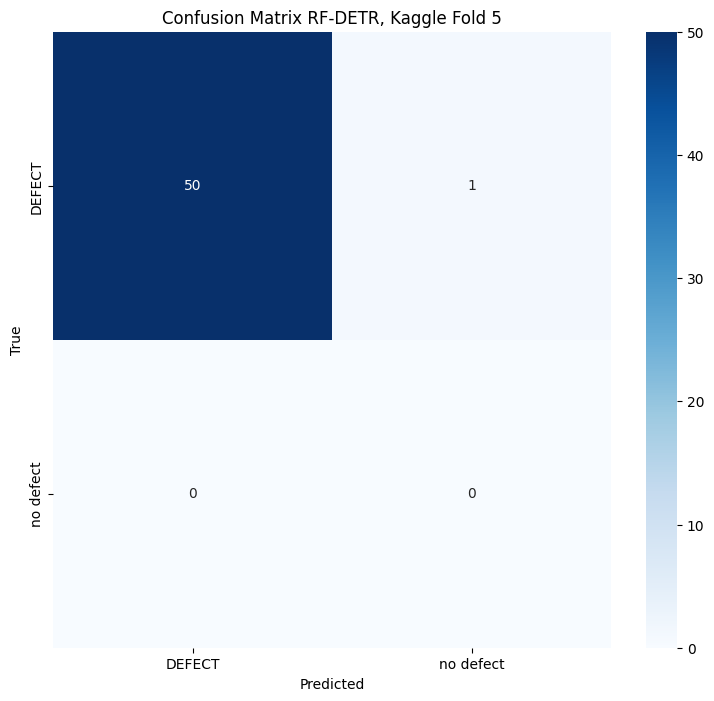


Consolidated 2x2 Matrix (True Row vs. Predicted Column):

           DEFECT  no defect
DEFECT         50          1
no defect       0          0


In [6]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. Construct the 2x2 Matrix Data ---
# Classes: 0=defect, 1=Background

# Row 0 (True: defect)

row_defect = [50, 1] 

# Row 1 (True: glass)

row_glass = [0, 0] 


cm_2x2_data = np.array([
    row_defect, 
    row_glass, 
])

labels_2x2 = ['DEFECT', 'no defect']


# --- 2. Plot the 2x2 Matrix ---
plt.figure(figsize=(9, 8))
sns.heatmap(
    cm_2x2_data, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    cbar=True,
    xticklabels=labels_2x2,
    yticklabels=labels_2x2
)

plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix RF-DETR, Kaggle Fold 5')
plt.show()

# Print the matrix for easy reference
print("\nConsolidated 2x2 Matrix (True Row vs. Predicted Column):\n")
df = pd.DataFrame(cm_2x2_data, index=labels_2x2, columns=labels_2x2)
print(df)

In [ ]:
TP=[53, 48, 49, 47, 50]
TN=[0, 0, 0, 0, 0]
FP=[1, 0, 0, 0, 0]
FN=[0, 0, 0, 0 , 1]
mAP50 = [1.00, 1.00, 1.00, 1.00, 0.980]
mAP5095 = [0.784, 0.885, 0.878, 0.881 , 0.864]
folds = ["Fold 1", "Fold 2", "Fold 3", "Fold 4", "Fold 5"]

# A list to store the results for each fold
results_per_fold = []

# Unpack the tuple from zip into meaningful variable names
for fold_name, tp_val, tn_val, fp_val, fn_val, map50_val, map5095_val in zip(folds, TP, TN, FP, FN, mAP50, mAP5095):
    # Handle division by zero for precision
    if (tp_val + fp_val) == 0:
        precision_rfdetr = 0.0
    else:
        precision_rfdetr = tp_val / (tp_val + fp_val)

    # Handle division by zero for recall
    if (tp_val + fn_val) == 0:
        recall_rfdetr = 0.0
    else:
        recall_rfdetr = tp_val / (tp_val + fn_val)
    
    # Handle division by zero for F1 score
    if (precision_rfdetr + recall_rfdetr) == 0:
        f1_rfdetr = 0.0
    else:
        f1_rfdetr = 2 * (precision_rfdetr * recall_rfdetr) / (precision_rfdetr + recall_rfdetr)
    
    # Create a dictionary for the current fold's results
    fold_results = {
        "Fold": fold_name,
        "Precision": precision_rfdetr,
        "Recall": recall_rfdetr,
        "F1": f1_rfdetr,
        "mAP50": map50_val,
        "mAP50-95": map5095_val
    }
    
    # Add the dictionary to our list of results
    results_per_fold.append(fold_results)

numeric_cols = [col for col in fold_results.keys() if col != "Fold"]

# Create a DataFrame from the list of dictionaries for a nice display
df_results = pd.DataFrame(results_per_fold)

df_results.style.format('{:.3f}', subset=numeric_cols).hide(axis="index")


Fold,Precision,Recall,F1,mAP50,mAP50-95
Fold 1,0.981,1.000,0.991,1.000,0.784
Fold 2,1.000,1.000,1.000,1.000,0.885
Fold 3,1.000,1.000,1.000,1.000,0.878
Fold 4,1.000,1.000,1.000,1.000,0.881
Fold 5,1.000,0.980,0.990,0.980,0.864


In [30]:
numeric_cols

[]

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. Construct the 3x3 Matrix Data ---
# Classes: 0=defect, 1=glass, 2=Background

# Row 0 (True: defect)
# P: defect (141), P: glass (1), P: Background (FN = 55)
row_defect = [141, 1, 55] 

# Row 1 (True: glass)
# P: defect (50), P: glass (173), P: Background (FN for glass, assumed 0)
row_glass = [0, 173, 0] 

# Row 2 (True: Background)
# P: defect (FP = 50), P: glass (FP for glass, assumed 0), P: Background (TN, assumed 0)
row_background = [50, 0, 0]

cm_3x3_data = np.array([
    row_defect, 
    row_glass, 
    row_background
])

labels_3x3 = ['defect', 'glass', 'no defect']


# --- 2. Plot the 3x3 Matrix ---
plt.figure(figsize=(9, 8))
sns.heatmap(
    cm_3x3_data, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    cbar=True,
    xticklabels=labels_3x3,
    yticklabels=labels_3x3
)

plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix RF-DETR, Roboflow')
plt.show()

# Print the matrix for easy reference
print("\nConsolidated 3x3 Matrix (True Row vs. Predicted Column):\n")
df = pd.DataFrame(cm_3x3_data, index=labels_3x3, columns=labels_3x3)
print(df)